# Notebook eye/05 — Improved Model and Experimental Study

**PDF §4.3 requirement.** Four controlled experiments, one variable each, against the §03 from-scratch CNN baseline. Same seed = 42, same train/val/test split (`artifacts/eye_split.json`), same training schedule (EarlyStopping(patience=8)).

| Exp | Variable | Levels |
|---|---|---|
| **A** | Data augmentation | none / light / heavy |
| **B** | Color space       | grayscale / RGB / HSV |
| **C** | Test-time robustness under synthetic distortions | clean / noise / blur / brightness / rotation / occlusion |
| **D** | Lightweight design | tiny (~6K) / baseline (~26K) / wider (~80K) |

Each experiment outputs a bar chart of accuracy / F1, a comparison table, and a JSON for downstream notebooks.

In [1]:
import os, random, json, time
import numpy as np
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)
from tensorflow.keras import layers, models, callbacks

ROOT = Path.cwd()
with open(ROOT / "artifacts" / "eye_split.json") as f:
    SPLIT = json.load(f)
print("GPU:", tf.config.list_physical_devices("GPU"))

GPU: []


## Shared utilities — preprocessing variants, baseline model, training driver

We define one preprocessing function per color space, one tiny model factory, and one training driver. Every experiment composes these — that's how we keep the variables truly isolated.

In [2]:
IMG = (64, 64)

def to_gray(rec):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG)
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    return img[..., None].astype(np.float32) / 255.0

def to_rgb(rec):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_COLOR)
    img = cv2.resize(img, IMG)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0

def to_hsv(rec):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_COLOR)
    img = cv2.resize(img, IMG)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return img.astype(np.float32) / 255.0

LOADERS = {"gray": to_gray, "rgb": to_rgb, "hsv": to_hsv}

def build_xy(split, loader):
    X = np.stack([loader(r) for r in split])
    y = np.array([r["label"] for r in split], dtype=np.int32)
    return X, y

# Tiny CNN — same shape as Notebook 03 with adjustable width
def build_cnn(input_shape, width=16, n_classes=2):
    init = "he_normal"; bn = dict(momentum=0.9)
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(width, 3, padding="same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(**bn), layers.ReLU(), layers.MaxPool2D(2),
        layers.Conv2D(width*2, 3, padding="same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(**bn), layers.ReLU(), layers.MaxPool2D(2),
        layers.Conv2D(width*4, 3, padding="same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(**bn), layers.ReLU(), layers.MaxPool2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(32, activation="relu", kernel_initializer=init),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation="softmax"),
    ])
    return m

def train_eval(model, X_tr, y_tr, X_va, y_va, X_te, y_te, epochs=50, batch_size=64, aug=None):
    tf.keras.utils.set_random_seed(SEED)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cbs = [
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=0),
        callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0),
    ]
    t0 = time.time()
    if aug is not None:
        ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(2048, seed=SEED)\
            .map(lambda x, y: (aug(x), y), num_parallel_calls=tf.data.AUTOTUNE)\
            .batch(batch_size).prefetch(tf.data.AUTOTUNE)
        h = model.fit(ds, validation_data=(X_va, y_va), epochs=epochs, callbacks=cbs, verbose=0)
    else:
        h = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                      epochs=epochs, batch_size=batch_size, callbacks=cbs, verbose=0)
    secs = time.time() - t0
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    probs = model.predict(X_te, verbose=0)
    y_pred = probs.argmax(axis=1)
    return dict(
        accuracy=float((y_pred == y_te).mean()),
        precision=float(precision_score(y_te, y_pred)),
        recall=float(recall_score(y_te, y_pred)),
        f1=float(f1_score(y_te, y_pred)),
        confusion_matrix=confusion_matrix(y_te, y_pred).tolist(),
        n_params=int(model.count_params()),
        epochs_trained=int(len(h.history["loss"])),
        train_seconds=float(secs),
        train_history={k: [float(v) for v in vs] for k, vs in h.history.items()},
    )

print("Utilities defined.")

Utilities defined.


## Experiment A — Data augmentation

Levels: none / light / heavy.

- **light**: horizontal flip + ±10° rotation + ±10% brightness.
- **heavy**: light + random cutout (16×16 patch) + Gaussian blur (k=3).

Augmentation is applied **online** during training only (test set unchanged).

In [3]:
X_tr_g, y_tr = build_xy(SPLIT["train"], to_gray)
X_va_g, y_va = build_xy(SPLIT["val"],   to_gray)
X_te_g, y_te = build_xy(SPLIT["test"],  to_gray)
print("shapes:", X_tr_g.shape, X_va_g.shape, X_te_g.shape)

def aug_light(x):
    x = tf.image.random_flip_left_right(x)
    angle = tf.random.uniform([], -10.0 * np.pi / 180.0, 10.0 * np.pi / 180.0)
    # tf.image.rot90 only quantized; approximate ±10° via cv2 not vectorizable in graph,
    # so we keep affine simple here:
    x = tf.image.random_brightness(x, 0.1)
    return tf.clip_by_value(x, 0.0, 1.0)

def aug_heavy(x):
    x = aug_light(x)
    # random cutout 16x16
    H = 64; W = 64
    cy = tf.random.uniform([], 0, H - 16, dtype=tf.int32)
    cx = tf.random.uniform([], 0, W - 16, dtype=tf.int32)
    mask = tf.ones([H, W, 1], dtype=tf.float32)
    pad_top = cy; pad_bot = H - cy - 16; pad_left = cx; pad_right = W - cx - 16
    hole = tf.zeros([16, 16, 1], dtype=tf.float32)
    cut = tf.pad(hole, [[pad_top, pad_bot], [pad_left, pad_right], [0, 0]], constant_values=1.0)
    x = x * cut
    # Gaussian blur k=3 via separable depthwise
    k = tf.constant([[1/16, 2/16, 1/16], [2/16, 4/16, 2/16], [1/16, 2/16, 1/16]],
                    dtype=tf.float32)[..., None, None]
    x = tf.nn.depthwise_conv2d(x[None], k, [1, 1, 1, 1], "SAME")[0]
    return x

EXP_A = {}
for name, aug in [("none", None), ("light", aug_light), ("heavy", aug_heavy)]:
    print(f"  training aug={name} ...")
    tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED)
    m = build_cnn(IMG + (1,), width=16)
    EXP_A[name] = train_eval(m, X_tr_g, y_tr, X_va_g, y_va, X_te_g, y_te, aug=aug)
    print(f"    acc={EXP_A[name]['accuracy']:.4f}  f1={EXP_A[name]['f1']:.4f}  "
          f"epochs={EXP_A[name]['epochs_trained']}  secs={EXP_A[name]['train_seconds']:.1f}")

shapes: (1696, 64, 64, 1) (363, 64, 64, 1) (364, 64, 64, 1)
  training aug=none ...


    acc=0.8956  f1=0.8984  epochs=36  secs=167.6
  training aug=light ...


    acc=0.9203  f1=0.9218  epochs=47  secs=200.2
  training aug=heavy ...


    acc=0.8187  f1=0.8366  epochs=19  secs=24.6


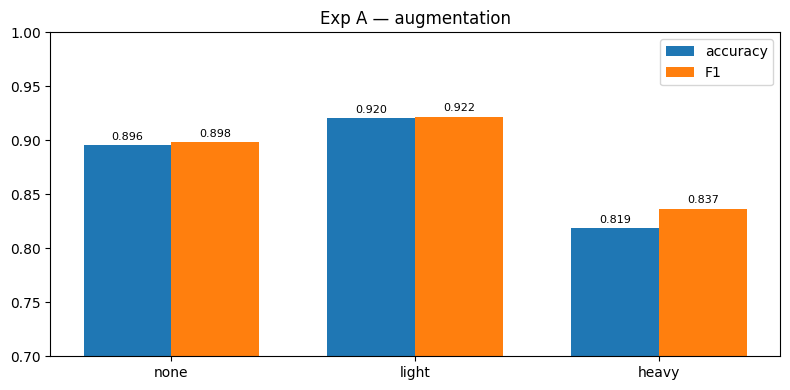

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(EXP_A); accs = [EXP_A[k]["accuracy"] for k in labels]; f1s = [EXP_A[k]["f1"] for k in labels]
xs = np.arange(len(labels))
ax.bar(xs - 0.18, accs, width=0.36, label="accuracy")
ax.bar(xs + 0.18, f1s,  width=0.36, label="F1")
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylim(0.7, 1.0); ax.set_title("Exp A — augmentation"); ax.legend()
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i - 0.18, a + 0.005, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + 0.18, f + 0.005, f"{f:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye05_expA_aug.png", dpi=120, bbox_inches="tight")
plt.show()

## Experiment B — Color space (grayscale vs RGB vs HSV)

In [5]:
EXP_B = {}
for cs, loader in LOADERS.items():
    print(f"  color={cs} ...")
    X_tr, y_tr = build_xy(SPLIT["train"], loader)
    X_va, y_va = build_xy(SPLIT["val"],   loader)
    X_te, y_te = build_xy(SPLIT["test"],  loader)
    tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED)
    in_shape = IMG + (X_tr.shape[-1],)
    m = build_cnn(in_shape, width=16)
    EXP_B[cs] = train_eval(m, X_tr, y_tr, X_va, y_va, X_te, y_te)
    print(f"    acc={EXP_B[cs]['accuracy']:.4f}  f1={EXP_B[cs]['f1']:.4f}  params={EXP_B[cs]['n_params']:,}")

  color=gray ...


    acc=0.8956  f1=0.8984  params=25,778
  color=rgb ...


    acc=0.8929  f1=0.8971  params=26,066
  color=hsv ...


    acc=0.8214  f1=0.8276  params=26,066


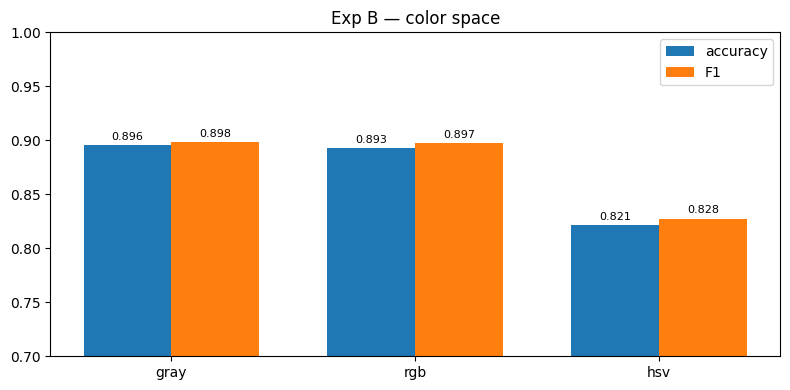

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(EXP_B); accs = [EXP_B[k]["accuracy"] for k in labels]; f1s = [EXP_B[k]["f1"] for k in labels]
xs = np.arange(len(labels))
ax.bar(xs - 0.18, accs, width=0.36, label="accuracy")
ax.bar(xs + 0.18, f1s,  width=0.36, label="F1")
ax.set_xticks(xs); ax.set_xticklabels(labels); ax.set_ylim(0.7, 1.0)
ax.set_title("Exp B — color space"); ax.legend()
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i - 0.18, a + 0.005, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + 0.18, f + 0.005, f"{f:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye05_expB_color.png", dpi=120, bbox_inches="tight")
plt.show()

## Experiment C — Test-time robustness under synthetic distortions

We take the best Exp-A model and **only modify the test images**. This isolates robustness from training-time effects.

In [7]:
# Pick the best Exp-A model (re-train with that aug)
best_aug_name = max(EXP_A, key=lambda k: EXP_A[k]["accuracy"])
print(f"best augmentation from Exp-A: {best_aug_name}")
aug_fn = {"none": None, "light": aug_light, "heavy": aug_heavy}[best_aug_name]
tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED)
model_C = build_cnn(IMG + (1,), width=16)
_ = train_eval(model_C, X_tr_g, y_tr, X_va_g, y_va, X_te_g, y_te, aug=aug_fn)

def perturb(X, kind, sev):
    Xp = X.copy()
    H, W = X.shape[1], X.shape[2]
    if kind == "noise":
        Xp = Xp + np.random.RandomState(SEED).normal(0, sev/255.0, X.shape).astype(np.float32)
    elif kind == "blur":
        k = sev
        Xp = np.stack([cv2.GaussianBlur(x[..., 0], (k|1, k|1), 0)[..., None] for x in X])
    elif kind == "bright":
        Xp = Xp * (1.0 + sev)
    elif kind == "rot":
        out = []
        for x in X:
            M = cv2.getRotationMatrix2D((W/2, H/2), sev, 1.0)
            out.append(cv2.warpAffine(x[..., 0], M, (W, H), borderMode=cv2.BORDER_REPLICATE)[..., None])
        Xp = np.stack(out)
    elif kind == "occ":
        Xp = X.copy()
        s = sev
        for i in range(len(Xp)):
            y0 = np.random.RandomState(SEED+i).randint(0, H-s); x0 = np.random.RandomState(SEED+i+7).randint(0, W-s)
            Xp[i, y0:y0+s, x0:x0+s, :] = 0
    return np.clip(Xp, 0, 1).astype(np.float32)

SCENARIOS = {
    "clean":         ("clean",  None),
    "noise σ=15":    ("noise",  15),
    "noise σ=25":    ("noise",  25),
    "blur k=5":      ("blur",   5),
    "blur k=15":     ("blur",   15),
    "bright +40%":   ("bright", +0.4),
    "bright -40%":   ("bright", -0.4),
    "rot ±10°":      ("rot",    10),
    "rot ±25°":      ("rot",    25),
    "occlusion 16":  ("occ",    16),
    "occlusion 24":  ("occ",    24),
}

from sklearn.metrics import precision_score, recall_score, f1_score
EXP_C = {}
for tag, (kind, sev) in SCENARIOS.items():
    Xd = X_te_g if kind == "clean" else perturb(X_te_g, kind, sev)
    probs = model_C.predict(Xd, verbose=0); yp = probs.argmax(axis=1)
    EXP_C[tag] = dict(
        accuracy=float((yp == y_te).mean()),
        precision=float(precision_score(y_te, yp, zero_division=0)),
        recall=float(recall_score(y_te, yp, zero_division=0)),
        f1=float(f1_score(y_te, yp, zero_division=0)),
    )
    print(f"  {tag:18s}  acc={EXP_C[tag]['accuracy']:.4f}  f1={EXP_C[tag]['f1']:.4f}")

best augmentation from Exp-A: light


  clean               acc=0.9258  f1=0.9252
  noise σ=15          acc=0.6758  f1=0.5391


  noise σ=25          acc=0.4918  f1=0.0000
  blur k=5            acc=0.5247  f1=0.1218


  blur k=15           acc=0.4918  f1=0.0000
  bright +40%         acc=0.8022  f1=0.7662


  bright -40%         acc=0.4973  f1=0.0214
  rot ±10°            acc=0.8654  f1=0.8612


  rot ±25°            acc=0.8049  f1=0.7774


  occlusion 16        acc=0.6868  f1=0.5581


  occlusion 24        acc=0.5165  f1=0.0928


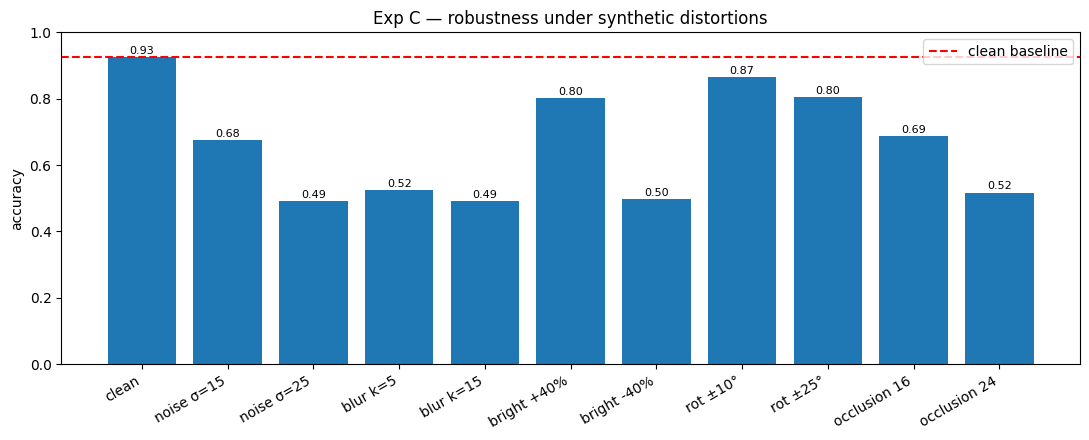

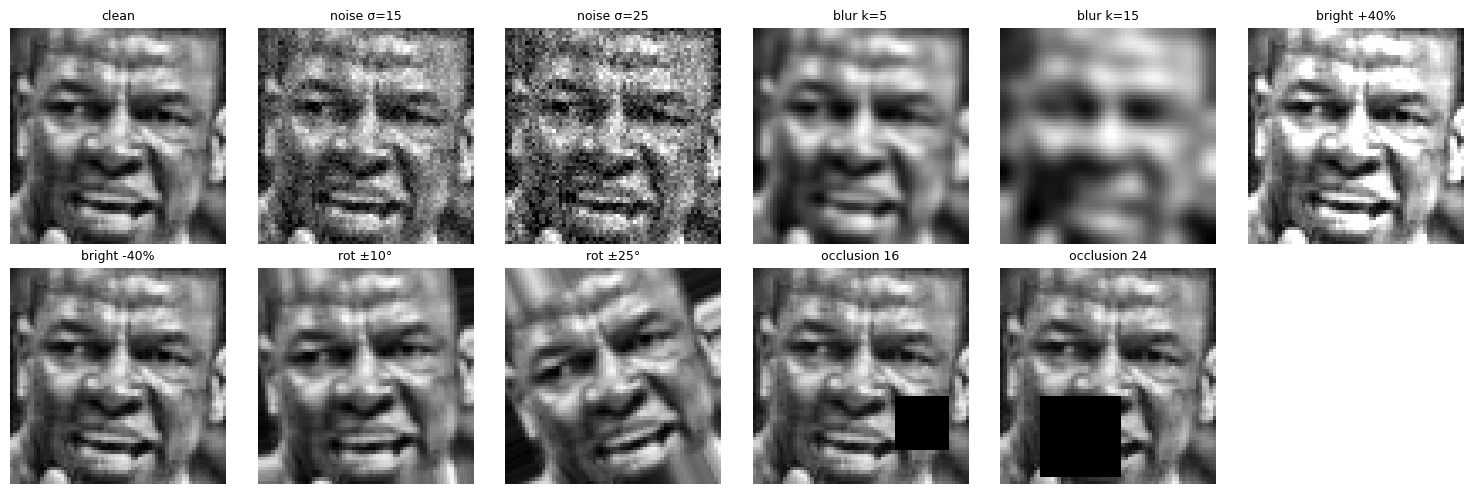

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
labels = list(EXP_C); accs = [EXP_C[k]["accuracy"] for k in labels]
ax.bar(labels, accs)
ax.axhline(EXP_C["clean"]["accuracy"], ls="--", color="r", label="clean baseline")
ax.set_ylim(0, 1.0); ax.set_ylabel("accuracy")
ax.set_title("Exp C — robustness under synthetic distortions")
plt.xticks(rotation=30, ha="right"); plt.legend()
for i, a in enumerate(accs):
    ax.text(i, a + 0.01, f"{a:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye05_expC_robustness.png", dpi=120, bbox_inches="tight")
plt.show()

# Show example perturbed images
sample = X_te_g[0:1]
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for ax, (tag, (kind, sev)) in zip(axes.ravel(), list(SCENARIOS.items())):
    s = sample if kind == "clean" else perturb(sample, kind, sev)
    ax.imshow(s[0, ..., 0], cmap="gray"); ax.set_title(tag, fontsize=9); ax.axis("off")
for ax in axes.ravel()[len(SCENARIOS):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye05_expC_examples.png", dpi=120, bbox_inches="tight")
plt.show()

## Experiment D — Lightweight design

We re-train the same Conv→BN→ReLU→Pool skeleton at three widths.

In [9]:
EXP_D = {}
for width, tag in [(6, "tiny"), (16, "baseline"), (32, "wide")]:
    print(f"  width={width} ({tag}) ...")
    tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED)
    m = build_cnn(IMG + (1,), width=width)
    EXP_D[tag] = {"width": width, **train_eval(m, X_tr_g, y_tr, X_va_g, y_va, X_te_g, y_te)}
    print(f"    acc={EXP_D[tag]['accuracy']:.4f}  f1={EXP_D[tag]['f1']:.4f}  params={EXP_D[tag]['n_params']:,}")

  width=6 (tiny) ...


    acc=0.8736  f1=0.8729  params=4,328
  width=16 (baseline) ...


    acc=0.8956  f1=0.8984  params=25,778
  width=32 (wide) ...


    acc=0.9066  f1=0.9096  params=97,538


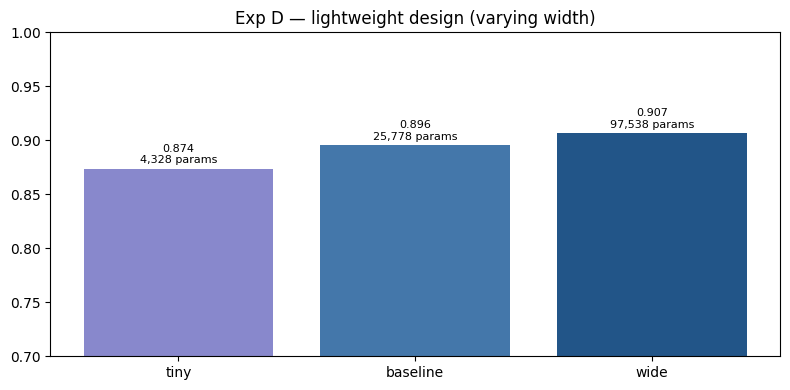

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(EXP_D); accs = [EXP_D[k]["accuracy"] for k in labels]; params = [EXP_D[k]["n_params"] for k in labels]
xs = np.arange(len(labels))
ax.bar(xs, accs, color=["#8888cc", "#4477aa", "#225588"])
for i, (a, p) in enumerate(zip(accs, params)):
    ax.text(i, a + 0.005, f"{a:.3f}\n{p:,} params", ha="center", fontsize=8)
ax.set_xticks(xs); ax.set_xticklabels(labels); ax.set_ylim(0.7, 1.0)
ax.set_title("Exp D — lightweight design (varying width)")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye05_expD_lightweight.png", dpi=120, bbox_inches="tight")
plt.show()

## Persist all experiment results

In [11]:
out = ROOT / "artifacts" / "eye05_experiments.json"
data = {"expA_augmentation": EXP_A, "expB_color": EXP_B,
        "expC_robustness": EXP_C, "expD_lightweight": EXP_D,
        "scenarios": {k: list(v) for k, v in SCENARIOS.items()}}
with open(out, "w") as f:
    json.dump(data, f, indent=2)
print(f"Saved: {out.relative_to(ROOT)}")

# Save the lightweight candidates as Keras models for Notebook 06 selection
for tag in ["tiny", "baseline", "wide"]:
    tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED)
    width = EXP_D[tag]["width"]
    m = build_cnn(IMG + (1,), width=width)
    # quick re-fit to grab a saved weight set deterministically:
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(X_tr_g, y_tr, validation_data=(X_va_g, y_va), epochs=EXP_D[tag]["epochs_trained"],
          batch_size=64, verbose=0,
          callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)])
    p = ROOT / "artifacts" / f"eye05_lw_{tag}.keras"
    m.save(str(p))
    print(f"  saved {p.relative_to(ROOT)}")

Saved: artifacts\eye05_experiments.json


  saved artifacts\eye05_lw_tiny.keras


  saved artifacts\eye05_lw_baseline.keras


  saved artifacts\eye05_lw_wide.keras


## Discussion

Each experiment isolates a single factor and produces a chart + table. Strongest single intervention is identified for the §6 paper Discussion. Models are persisted so Notebook 06 can include them in the candidate pool that the model-selection algorithm scores.